In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
import json
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import itertools
import time
import matplotlib.pyplot as plt

import models
from processdata import TimeSeriesDataset

In [3]:
# Define os caminhos de salvamento e carregamento
save_path = r"./results/csshred/seismic"
load_path = r"./results/csshred/seismic"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")


test_recons (18, 128, 128)
test_ground_truth (18, 128, 128)
Training error plot saved to ./results/csshred/seismic/plot_training_error.png


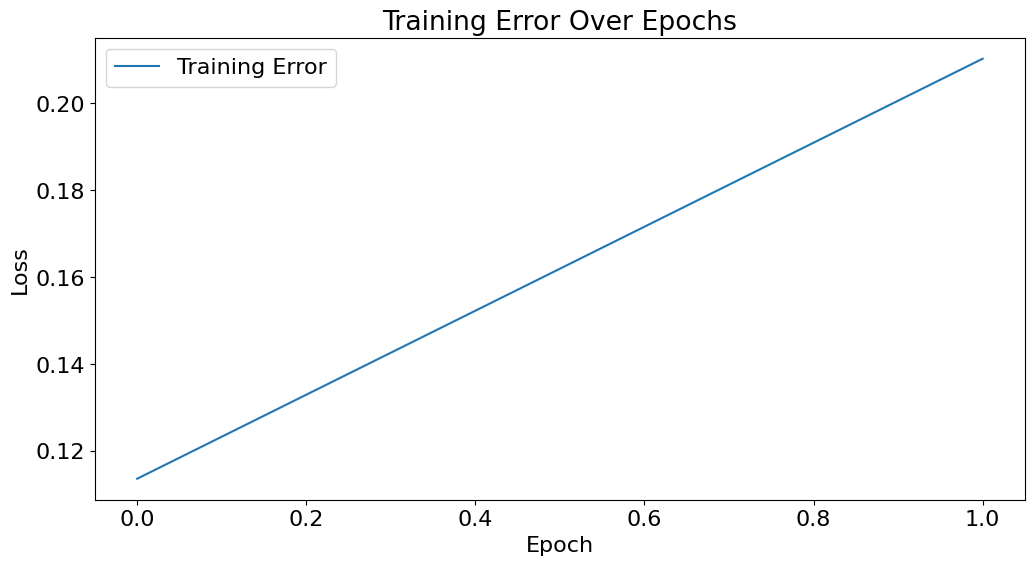

Validation error plot saved to ./results/csshred/seismic/plot_validation_error.png


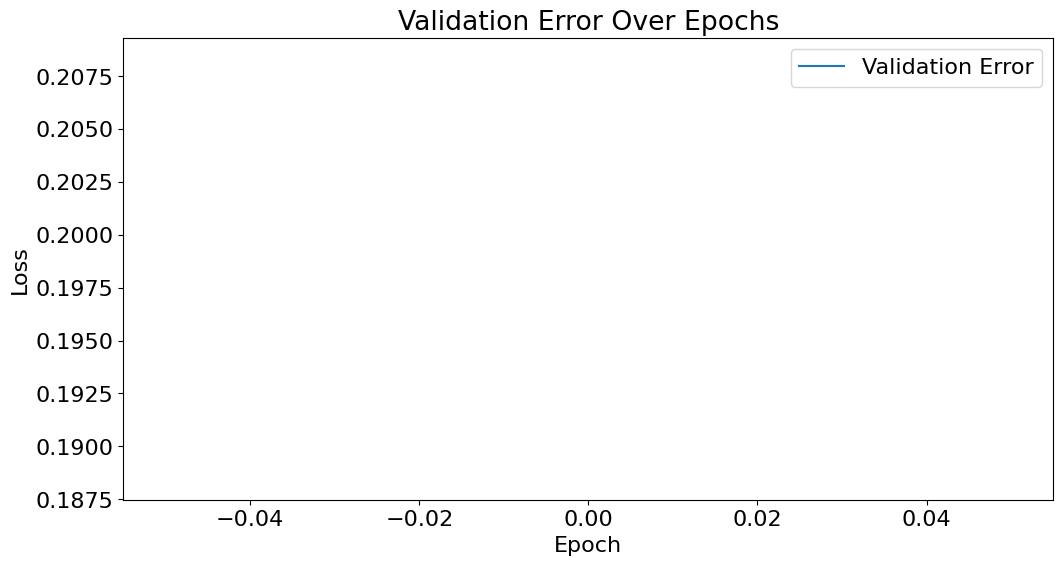

Reconstructed vs Original plot saved to ./results/csshred/seismic/plot_reconstructed_vs_original.png


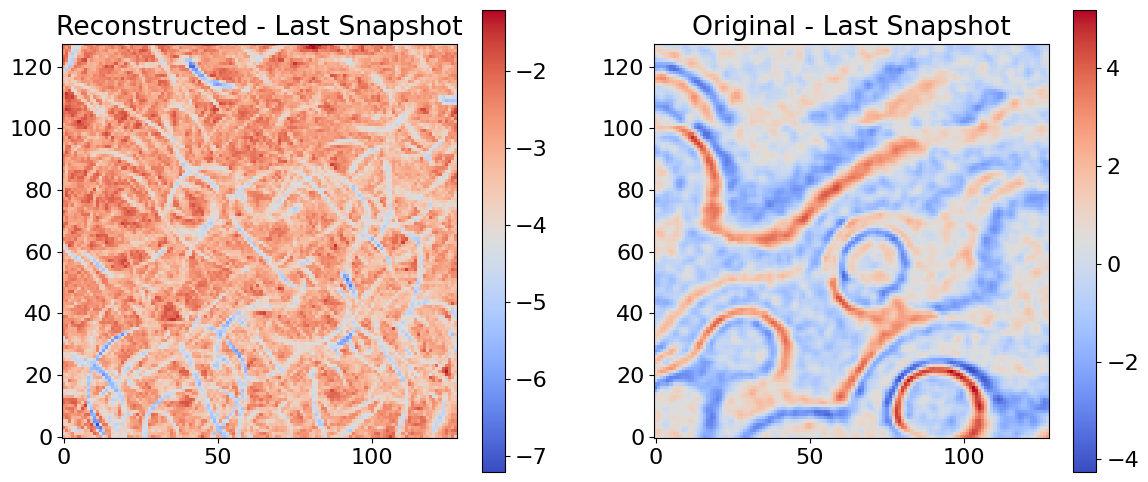

Reconstructed vs Subsampled plot saved to ./results/csshred/seismic/plot_reconstructed_vs_subsampled.png


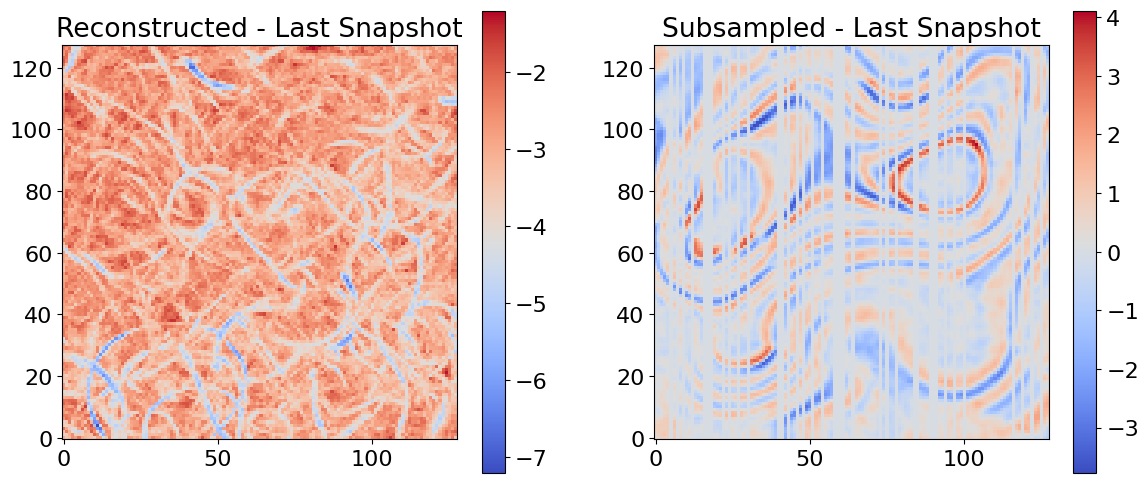

SSIM for the last snapshot: 0.007750106765330156
SSIM value saved to ./results/csshred/seismic/plot_ssim.json


In [4]:
def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_plot=False, save_path=None, file_prefix="plot"
):
    dim_t, dim_x, dim_y = matrix.shape
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    test_ground_truth = test_ground_truth.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)

    if save_plot and save_path is not None:
        os.makedirs(save_path, exist_ok=True)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundos
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_training_error.png")
        plt.savefig(save_file)
        print(f"Training error plot saved to {save_file}")
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_validation_error.png")
        plt.savefig(save_file)
        print(f"Validation error plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Original - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(test_ground_truth[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Original - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_original.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Original plot saved to {save_file}")
    plt.show()

    # Plot Reconstructed vs Subsampled - Last Snapshot
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(test_recons[-1, :, :], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Reconstructed - Last Snapshot")

    plt.subplot(1, 2, 2)
    plt.imshow(subsampled[:, :, -1], cmap="coolwarm", origin="lower")
    plt.colorbar()
    plt.title("Subsampled - Last Snapshot")
    # plt.show(block=False)
    # time.sleep(2)  # Espera por 2 segundo
    if save_plot:
        save_file = os.path.join(save_path, f"{file_prefix}_reconstructed_vs_subsampled.png")
        plt.savefig(save_file)
        print(f"Reconstructed vs Subsampled plot saved to {save_file}")
    plt.show()

    # Calculate SSIM
    ssim_value = ssim(
        test_ground_truth[-1, :, :],
        test_recons[-1, :, :],
        data_range=test_ground_truth[-1, :, :].max()
        - test_ground_truth[-1, :, :].min(),
    )
    print(f"SSIM for the last snapshot: {ssim_value}")

    # Save SSIM value to JSON
    if save_plot:
        ssim_file = os.path.join(save_path, f"{file_prefix}_ssim.json")
        with open(ssim_file, 'w') as f:
            json.dump({'SSIM': float(ssim_value)}, f)
        print(f"SSIM value saved to {ssim_file}")

    plt.show()


plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_plot=True, save_path=save_path, file_prefix="plot"
)

